In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harishkumardatalab/food-image-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.68G/1.68G [00:19<00:00, 91.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/harishkumardatalab/food-image-classification-dataset/versions/1


In [ ]:
import os

# Check dataset folder structure
# Note: kagglehub usually downloads to a root folder; we need to find the directory containing image classes
def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        if len(files) > 0:
            print(f'{subindent}{len(files)} files found.')
        if level >= 2: break # Only view basic structure

list_files(path)

1/
    Food Classification dataset/
        pav_bhaji/
            305 files found.


### Split Dataset into Train/Test (8/2)

The code below will collect the paths for all images and their corresponding labels (folder names), then use `train_test_split` to partition the data.

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Fix: Point to the actual directory containing the food categories
dataset_root = os.path.join(path, "Food Classification dataset")

all_images = []
all_labels = []

# Iterate through subdirectories (each directory is a label/food category)
if os.path.exists(dataset_root):
    for category in os.listdir(dataset_root):
        category_path = os.path.join(dataset_root, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(os.path.join(category_path, img_name))
                    all_labels.append(category)

# Check if data was found
if len(all_images) == 0:
    print("Error: No images found. Please check the directory structure.")
else:
    # Create a DataFrame for easier management
    df = pd.DataFrame({'image_path': all_images, 'label': all_labels})

    # Split the dataset into 80% Train and 20% Test
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['label']
    )

    print(f"Total images found: {len(df)}")
    print(f"Number of images in Train set: {len(train_df)}")
    print(f"Number of images in Test set: {len(test_df)}")

    # Display the first 5 rows of the Train set
    display(train_df.head())

Total images found: 23873
Number of images in Train set: 19098
Number of images in Test set: 4775


,image_path,label
9029,/root/.cache/kagglehub/datasets/harishkumardat...,Crispy Chicken
8859,/root/.cache/kagglehub/datasets/harishkumardat...,Crispy Chicken
6670,/root/.cache/kagglehub/datasets/harishkumardat...,Hot Dog
11078,/root/.cache/kagglehub/datasets/harishkumardat...,Taco
11201,/root/.cache/kagglehub/datasets/harishkumardat...,Taco


In [ ]:
import tensorflow as tf

# Check if GPU is available
print("TensorFlow version:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

# List physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

TensorFlow version: 2.20.0
Found GPU at: /device:GPU:0
Num GPUs Available:  1


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = train_df['label'].nunique()

# Create Image Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Build VGG16 Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Fixed the loss function identifier typo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Start training
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Found 19098 validated image filenames belonging to 34 classes.
Found 4775 validated image filenames belonging to 34 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
 46/597 ━━━━━━━━━━━━━━━━━━━━ 4:52 532ms/step - accuracy: 0.0548 - loss: 5.1732

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


597/597 ━━━━━━━━━━━━━━━━━━━━ 387s 624ms/step - accuracy: 0.0924 - loss: 3.2819 - val_accuracy: 0.1386 - val_loss: 3.0174
Epoch 2/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 346s 579ms/step - accuracy: 0.1021 - loss: 3.1147 - val_accuracy: 0.1715 - val_loss: 2.8995
Epoch 3/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 344s 577ms/step - accuracy: 0.1113 - loss: 3.0673 - val_accuracy: 0.1902 - val_loss: 2.8024
Epoch 4/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 347s 581ms/step - accuracy: 0.1229 - loss: 3.0044 - val_accuracy: 0.2034 - val_loss: 2.7458
Epoch 5/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 343s 574ms/step - accuracy: 0.1320 - loss: 2.9746 - val_accuracy: 0.2226 - val_loss: 2.7264
Epoch 6/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 343s 575ms/step - accuracy: 0.1343 - loss: 2.9448 - val_accuracy: 0.2415 - val_loss: 2.6439
Epoch 7/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 342s 572ms/step - accuracy: 0.1366 - loss: 2.9427 - val_accuracy: 0.2327 - val_loss: 2.6259
Epoch 8/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 343s 574ms/step - accuracy: 0.1376 - loss: 2.93

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Print summary of class indices
print("Class Indices:", train_generator.class_indices)

150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.2515 - loss: 2.6636
Test Loss: 2.6636
Test Accuracy: 0.2515
Class Indices: {'Baked Potato': 0, 'Crispy Chicken': 1, 'Donut': 2, 'Fries': 3, 'Hot Dog': 4, 'Sandwich': 5, 'Taco': 6, 'Taquito': 7, 'apple_pie': 8, 'burger': 9, 'butter_naan': 10, 'chai': 11, 'chapati': 12, 'cheesecake': 13, 'chicken_curry': 14, 'chole_bhature': 15, 'dal_makhani': 16, 'dhokla': 17, 'fried_rice': 18, 'ice_cream': 19, 'idli': 20, 'jalebi': 21, 'kaathi_rolls': 22, 'kadai_paneer': 23, 'kulfi': 24, 'masala_dosa': 25, 'momos': 26, 'omelette': 27, 'paani_puri': 28, 'pakode': 29, 'pav_bhaji': 30, 'pizza': 31, 'samosa': 32, 'sushi': 33}


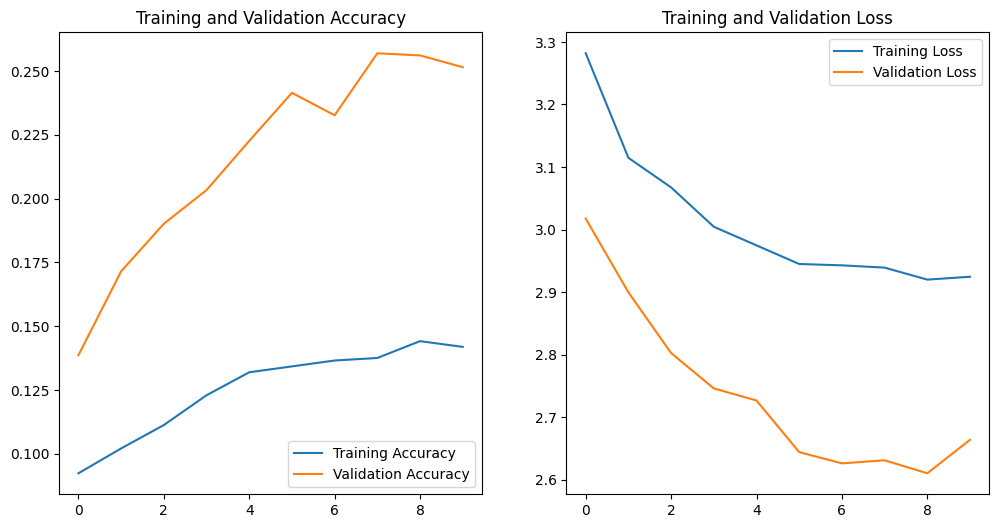

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy/Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()